In [8]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict, List, Dict, Any, Optional


In [10]:
class AgentState(TypedDict):
    first_number: int
    second_number: int
    operation: str
    result: Optional[int]


In [11]:
def addition(state: AgentState) -> AgentState:
    state["result"] = state["first_number"] + state["second_number"]
    return state
def subtraction(state: AgentState) -> AgentState:
    state["result"] = state["first_number"] - state["second_number"]
    return state

def next_node(state: AgentState) -> str:
    if state["operation"] == "+":
        return "addition"
    elif state["operation"] == "-":
        return "subtraction"




In [12]:
graph = StateGraph(AgentState)
graph.add_node("addition_node", addition)
graph.add_node("subtraction_node", subtraction)
graph.add_node("router",lambda state:state)


In [13]:
graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    next_node,
    {
        #edge   :   node
        "addition" : "addition_node",
        "subtraction": "subtraction_node"
        
    }
    
)
graph.add_edge("addition_node", END)
graph.add_edge("subtraction_node", END)
app = graph.compile()


In [14]:
result = app.invoke({"first_number":23,"second_number":53,"operation" :'+'})
print(result)

{'first_number': 23, 'second_number': 53, 'operation': '+', 'result': 76}


In [ ]:
from IPython.display import Image, display

display(
    Image(app.get_graph().draw_mermaid_png())
)

### HomeWork Question 


In [16]:
class AgentState(TypedDict):
    first_number: int
    second_number: int
    operation1: str
    third_number : int
    fourth_number : int
    opertion2: str
    final_number1: Optional[int]
    final_number2: int

In [18]:
def addition(state: AgentState) -> AgentState:
    state["result"] = state["first_number"] + state["second_number"]
    return state
def subtraction(state: AgentState) -> AgentState:
    state["result"] = state["first_number"] - state["second_number"]
    return state

def next_node(state: AgentState) -> str:
    '''gives next edges'''
    if state["operation"] == "+":
        return "addition"
    elif state["operation"] == "-":
        return "subtraction"


In [19]:
graph = StateGraph(AgentState)
graph.add_node("addition_node1", addition)
graph.add_node("subtraction_node1", subtraction)
graph.add_node("router",lambda state:state)
graph.add_node("addition_node2",addition)
graph.add_node("subtraction_node2", subtraction)
graph.add_node("router2",lambda state:state)





In [20]:
graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    next_node,
    {
        #edge   :   node
        "addition" : "addition_node1",
        "subtraction": "subtraction_node1"
        
    }
    
)
graph.add_edge("addition_node1","router2"),
graph.add_edge("subtraction_node1","router2")

graph.add_conditional_edges(
    "router2",
    next_node,
    {
        #edge   :   node
        "addition" : "addition_node2",
        "subtraction": "subtraction_node2"
        
    }
    
)
app = graph.compile()

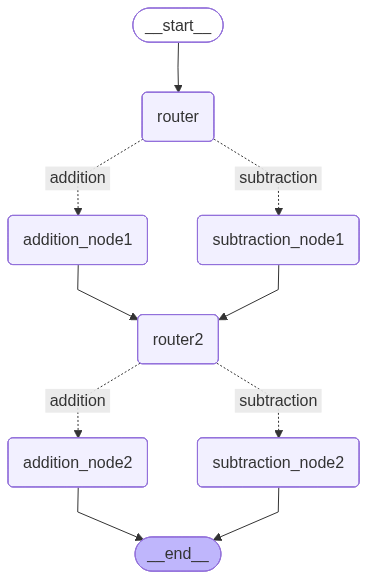

In [21]:
from IPython.display import Image, display

display(
    Image(app.get_graph().draw_mermaid_png())
)